Rows: 438600
Columns: 36

 Sample columns: ['ts_hour', 'date', 'zone_id', 'zone_name', 'year', 'month', 'day', 'dow', 'hour', 'is_weekend', 'is_holiday', 'is_general_holiday', 'holiday_name', 'holiday_category', 'pre_holiday_flag', 'post_holiday_flag', 'is_ramadan', 'is_ramadan_evening', 'is_eid', 'temp_c', 'is_rain', 'rain_mm', 'traffic_index', 'event_intensity_city', 'requests']

 Usiing features: ['available_drivers', 'rain_mm', 'traffic_index', 'event_intensity_city', 'is_weekend', 'is_ramadan', 'hour']

Dropped rows due to missing/inf :0(Remaining:438600)

 Boolean columns detected: []
Dropped rows after numeric coercion :0(Remaining:438600)


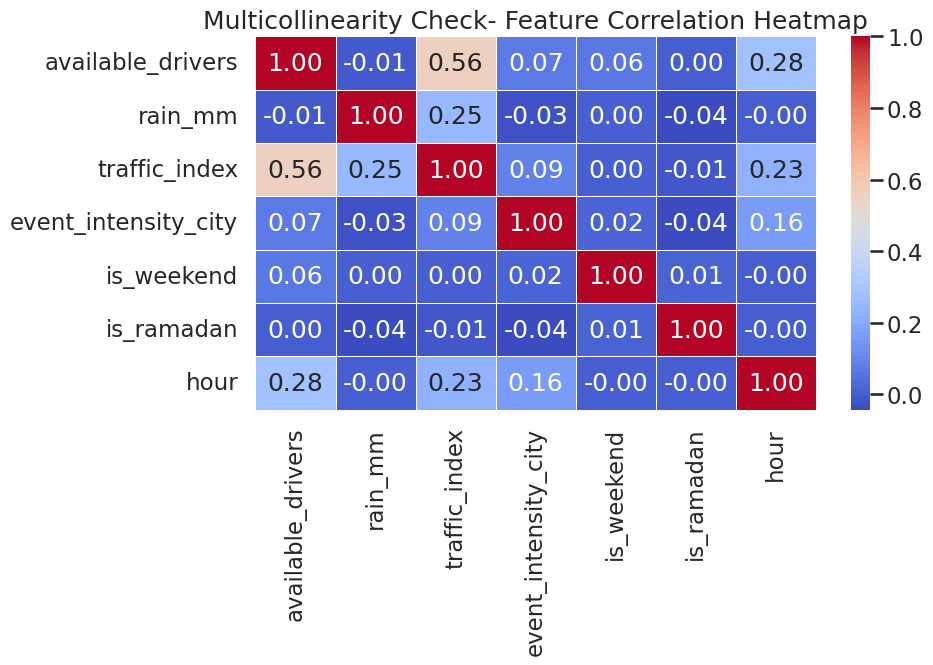


==================VIF TABLE====================


feature,VIF
const,43.505
traffic_index,1.624
available_drivers,1.564
hour,1.118
rain_mm,1.11
event_intensity_city,1.034
is_weekend,1.007
is_ramadan,1.004


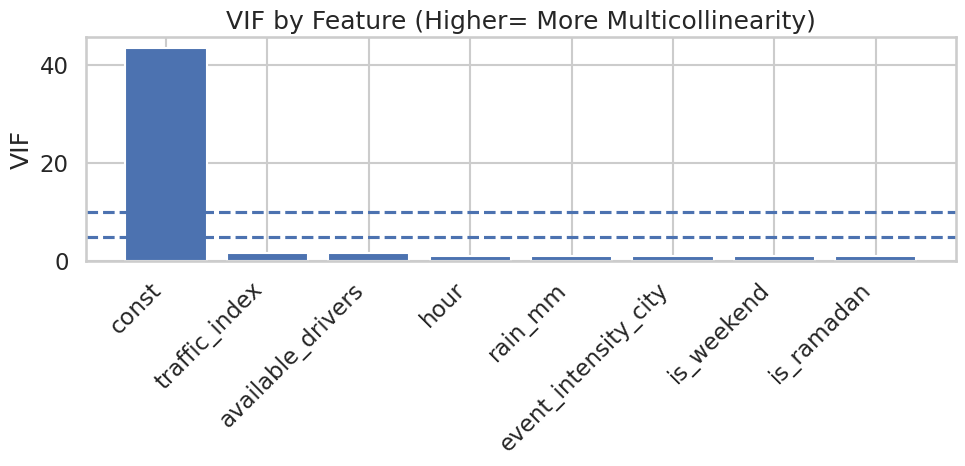

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns",300)
pd.set_option("display.width",180)
pd.set_option("display.float_format","{:,.4f}".format)
sns.set_theme(style="whitegrid", context="talk")
fact_zone_hour = spark.table("workspace.rapido.fact_zone_hour").toPandas()
print("Rows:", len(fact_zone_hour))
print("Columns:",fact_zone_hour.shape[1])
print("\n Sample columns:", list(fact_zone_hour.columns)[:25])

TARGET = "requests"
FEATURES=[
    "available_drivers",
    "rain_mm",
    "traffic_index",
    "event_intensity_city",
    "is_weekend",
    "is_ramadan",
    "hour"
]


existing_features = [c for c in FEATURES if c in fact_zone_hour.columns]
missing_features=[c for c in FEATURES if c not in fact_zone_hour.columns]

if missing_features:
    print("\n Missing features:", existing_features)
print("\n Usiing features:", existing_features)
model_df = fact_zone_hour[existing_features +[TARGET]].copy()
model_df.replace([np.inf, -np.inf],np.nan,inplace=True)
before= len(model_df)
model_df.dropna(subset= existing_features +[TARGET], inplace=True)
after= len(model_df)
print(f"\nDropped rows due to missing/inf :{before- after}(Remaining:{after})")
bool_cols = model_df.select_dtypes(include=["bool"]).columns.tolist()
print("\n Boolean columns detected:", bool_cols)

for c in bool_cols:
    model_df[c] = model_df[c].astype(int)
model_df[existing_features +[TARGET]]= model_df[existing_features+[TARGET]].apply(pd.to_numeric, errors="coerce")

before2 = len(model_df)
model_df.dropna(subset = existing_features + [TARGET], inplace=True)
after2 = len(model_df)
print(f"Dropped rows after numeric coercion :{before2-after2}(Remaining:{after2})")
X_vis = model_df[existing_features].copy()
corr= X_vis.corr(numeric_only= True)
plt.figure(figsize=(10,7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap= "coolwarm",
    linewidth=0.5
)

plt.title("Multicollinearity Check- Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

X_vif = X_vis.copy()
X_vif_const= sm.add_constant(X_vif)
vif_data =[]
for i in range(X_vif_const.shape[1]):
    col_name=X_vif_const.columns[i]
    vif_val = variance_inflation_factor(X_vif_const.values, i)
    vif_data.append((col_name, vif_val))

vif_df = pd.DataFrame(vif_data, columns=["feature", "VIF"]).sort_values("VIF", ascending=False)
print("\n==================VIF TABLE====================")
display(vif_df.round(3))
plt.figure(figsize=(10,5))
plt.bar(vif_df["feature"], vif_df["VIF"])
plt.xticks(rotation= 45, ha= "right")
plt.axhline(5, linestyle="--")
plt.axhline(10, linestyle="--")
plt.title("VIF by Feature (Higher= More Multicollinearity)")
plt.ylabel("VIF")
plt.tight_layout()
plt.show()

In [0]:
final_features = existing_features.copy()
X = model_df[final_features].copy()
y = model_df[TARGET].copy()
X_train, X_test, y_train, y_test= train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
) 

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)
ols_model = sm.OLS(y_train, X_train_sm).fit()

print("\n ======OLS SUMMARY=======")
print(ols_model.summary())
y_train_pred = ols_model.predict(X_train_sm)
y_test_pred = ols_model.predict(X_test_sm)
def safe_mape(y_true, y_pred, eps= 1e-9):
    return np.mean(np.abs((y_true-y_pred)/(np.abs(y_true)+eps)))*100

kpi_df = pd.DataFrame({
    "Dataset":["Train","Test"],
    "R2":[
        r2_score(y_train, y_train_pred),
        r2_score(y_test, y_test_pred)
    ],
    "MAE":[
        mean_absolute_error(y_train, y_train_pred),
        mean_absolute_error(y_test, y_test_pred)
    ],
    "MSE":[
        mean_squared_error(y_train, y_train_pred),
        mean_squared_error(y_test, y_test_pred)
    ],
    "MSE":[
        mean_squared_error(y_train, y_train_pred),
        mean_squared_error(y_test, y_test_pred)
    ],
    "RMSE":[
        np.sqrt(mean_squared_error(y_train, y_train_pred)),
        np.sqrt(mean_squared_error(y_test, y_test_pred))
    ],
    "MAPE_%":[
        safe_mape(y_train, y_train_pred),
        safe_mape(y_test, y_test_pred)
    ]
                 
})

print("\n =============MODEL PREFORMANCE KPI'S (TRAIN AND TEST)==========")
display(kpi_df.round(3))
ols_inference_df = pd.DataFrame({
    "Metric":[
        "R2(Train)",
        "Adjusted R2 (Train)",
        "F- statistic",
        "F-stat p-value",
        "AIC",
        "BIC"
    ],
    "value":[
        ols_model.rsquared,
        ols_model.rsquared_adj,
        ols_model.fvalue,
        ols_model.f_pvalue,
        ols_model.aic,
        ols_model.bic
    ]
})


print("\n =========OLS INFERENCE KPI'S=========")
display(ols_inference_df.round(3))


 ======OLS SUMMARY=======
                            OLS Regression Results                            
Dep. Variable:               requests   R-squared:                       0.525
Model:                            OLS   Adj. R-squared:                  0.525
Method:                 Least Squares   F-statistic:                 5.530e+04
Date:                Sat, 31 Jan 2026   Prob (F-statistic):               0.00
Time:                        13:45:16   Log-Likelihood:            -1.2684e+06
No. Observations:              350880   AIC:                         2.537e+06
Df Residuals:                  350872   BIC:                         2.537e+06
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const

Dataset,R2,MAE,MSE,RMSE,MAPE_%
Train,0.525,6.719,80.784,8.988,5.35601620865E8
Test,0.526,6.709,80.215,8.956,5.67342905559E8



 =========OLS INFERENCE KPI'S=========


Metric,value
R2(Train),0.525
Adjusted R2 (Train),0.525
F- statistic,55299.389
F-stat p-value,0.0
AIC,2536758.753
BIC,2536844.898


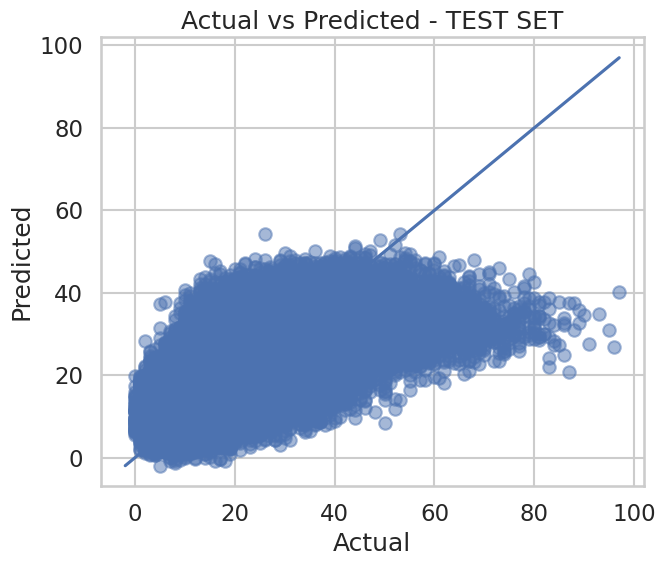

In [0]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted - TEST SET")

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(),y_test_pred.max())

plt.plot([min_val,max_val],[min_val,max_val])
plt.tight_layout()
plt.show()

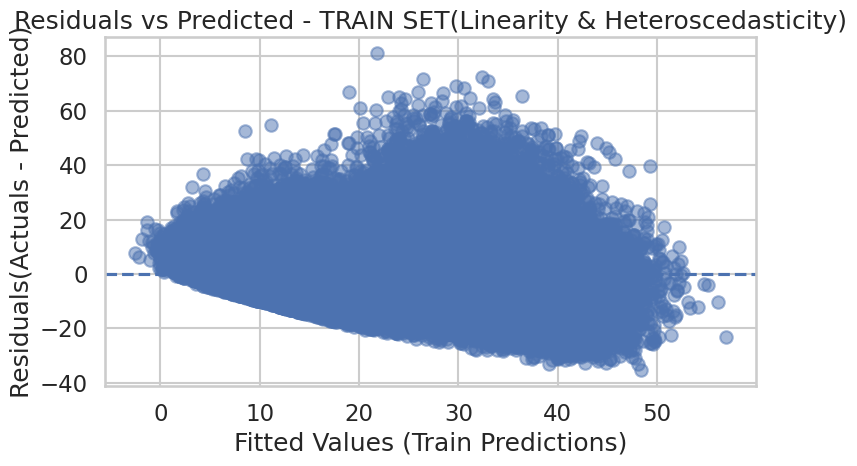

In [0]:
train_residuals = y_train - y_train_pred
plt.figure(figsize=(8,5))
plt.scatter(y_train_pred, train_residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted Values (Train Predictions)")
plt.ylabel("Residuals(Actuals - Predicted)")
plt.title("Residuals vs Predicted - TRAIN SET(Linearity & Heteroscedasticity)")
plt.tight_layout()
plt.show()

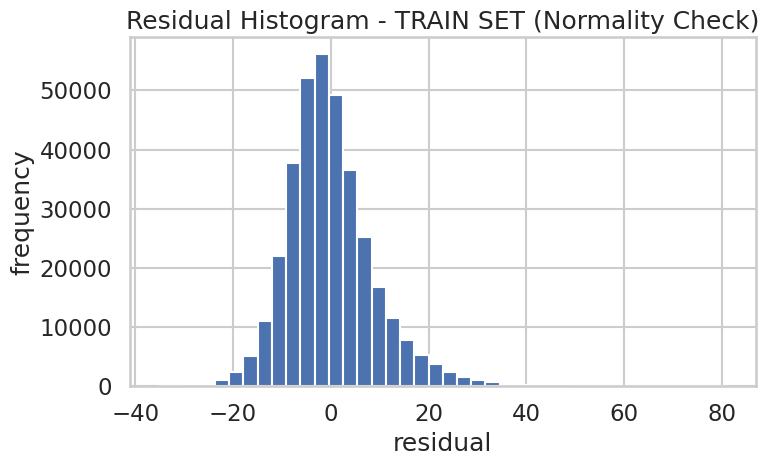

In [0]:
plt.figure(figsize=(8,5))
plt.hist(train_residuals, bins=40)
plt.title("Residual Histogram - TRAIN SET (Normality Check)")
plt.xlabel("residual")
plt.ylabel("frequency")
plt.tight_layout()
plt.show()


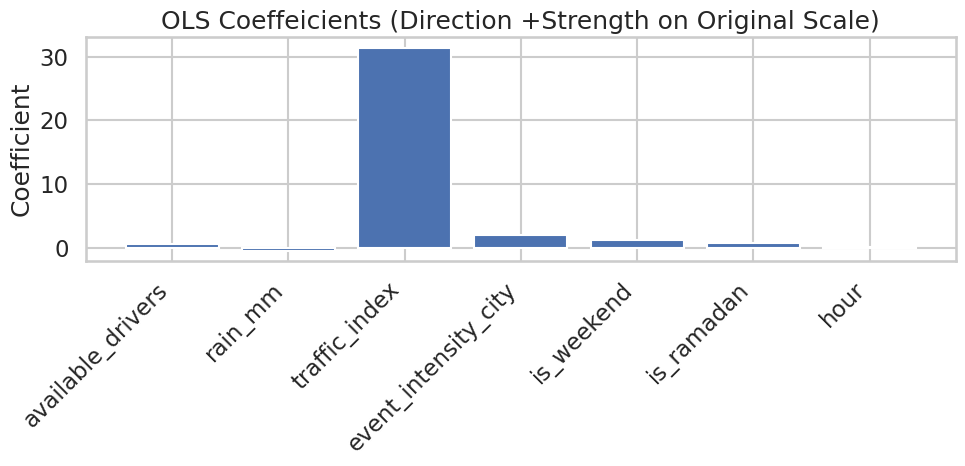

In [0]:
coef_series = ols_model.params.drop("const", errors="ignore").copy()

plt.figure(figsize=(10,5))
plt.bar(coef_series.index, coef_series.values)
plt.xticks(rotation= 45, ha="right")
plt.title("OLS Coeffeicients (Direction +Strength on Original Scale)")
plt.ylabel("Coefficient")
plt.tight_layout()
plt.show()